# This is a Training modle of magic diagonisis 

in this modle we have to find where the ray is gaama or hydron

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler

In [37]:
data=pd.read_csv("magic04.data")
data

,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.011,-8.2027,40.092,81.8828,g
0,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
1,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
2,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
3,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g
4,51.6240,21.1502,2.9085,0.2420,0.1340,50.8761,43.1887,9.8145,3.6130,238.0980,g
...,...,...,...,...,...,...,...,...,...,...,...
19014,21.3846,10.9170,2.6161,0.5857,0.3934,15.2618,11.5245,2.8766,2.4229,106.8258,h
19015,28.9452,6.7020,2.2672,0.5351,0.2784,37.0816,13.1853,-2.9632,86.7975,247.4560,h
19016,75.4455,47.5305,3.4483,0.1417,0.0549,-9.3561,41.0562,-9.4662,30.2987,256.5166,h
19017,120.5135,76.9018,3.9939,0.0944,0.0683,5.8043,-93.5224,-63.8389,84.6874,408.3166,h


In [38]:
data.head(20)


,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.011,-8.2027,40.092,81.8828,g
0,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
1,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
2,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
3,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g
4,51.6240,21.1502,2.9085,0.2420,0.1340,50.8761,43.1887,9.8145,3.6130,238.0980,g
5,48.2468,17.3565,3.0332,0.2529,0.1515,8.5730,38.0957,10.5868,4.7920,219.0870,g
6,26.7897,13.7595,2.5521,0.4236,0.2174,29.6339,20.4560,-2.9292,0.8120,237.1340,g
7,96.2327,46.5165,4.1540,0.0779,0.0390,110.3550,85.0486,43.1844,4.8540,248.2260,g
8,46.7619,15.1993,2.5786,0.3377,0.1913,24.7548,43.8771,-6.6812,7.8750,102.2510,g
9,62.7766,29.9104,3.3331,0.2475,0.1261,-33.9065,57.5848,23.7710,9.9144,323.0940,g


Rading the Data set 

In [39]:
colms=["flength","fwidth","fSize","fcone","fconcl","fAsym","fM3Long","fM3Trans","fAlpha","fDist","class"]
df=pd.read_csv("magic04.data",names=colms)



Now our computer dosent understand the difference between g and h so what we are going to do is place 1 in the place of g and 0 for hydron h

In [40]:
print(df["class"].head(10).tolist())
print(df["class"].unique())
print(repr(df["class"].iloc[0]))
print(type(df["class"].iloc[0]))

['g', 'g', 'g', 'g', 'g', 'g', 'g', 'g', 'g', 'g']
<StringArray>
['g', 'h']
Length: 2, dtype: str
'g'
<class 'str'>


In [41]:
df["class"] = (df["class"]=="g").astype(int)
print(df["class"].unique())

[1 0]


In [42]:
df.head()

,flength,fwidth,fSize,fcone,fconcl,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,1
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,1
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,1
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,1
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,1


In [43]:
df["class"]


0        1
1        1
2        1
3        1
4        1
        ..
19015    0
19016    0
19017    0
19018    0
19019    0
Name: class, Length: 19020, dtype: int64

# Comparing by Histogram

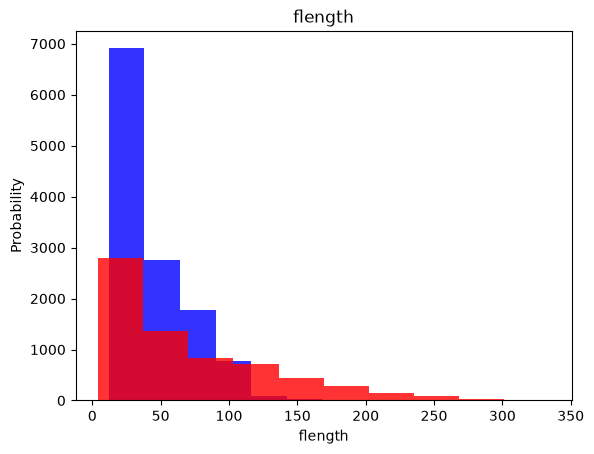

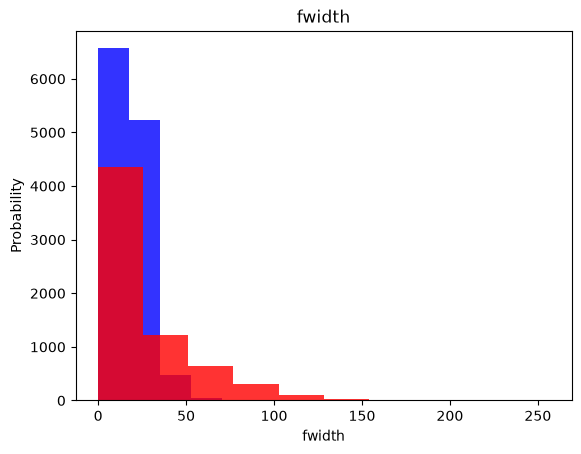

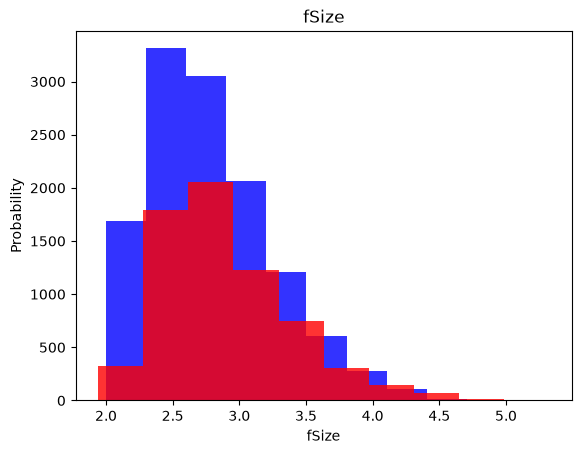

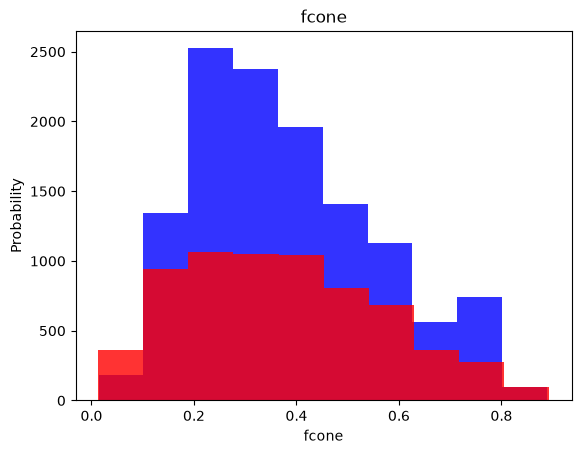

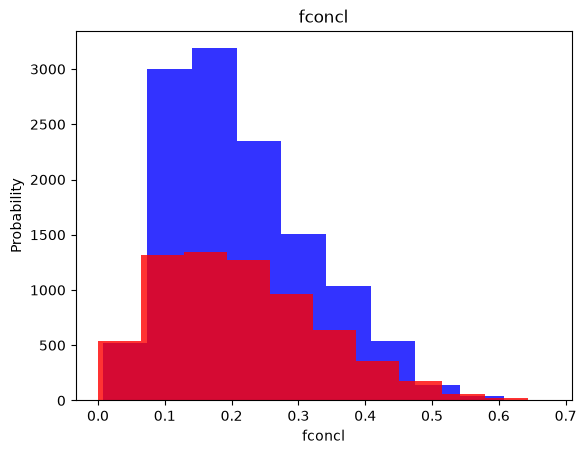

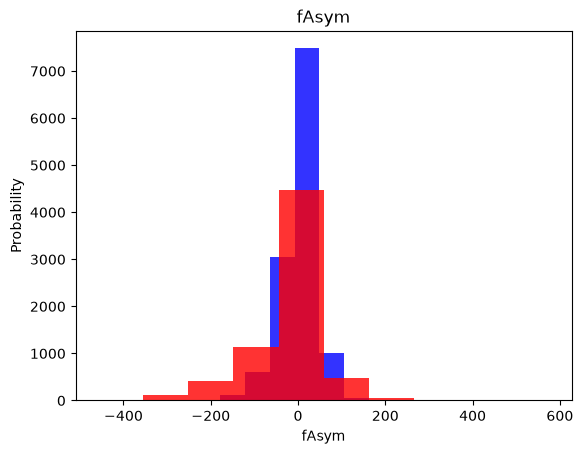

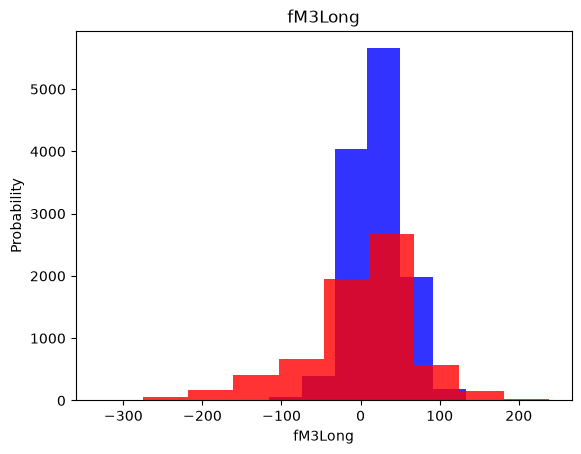

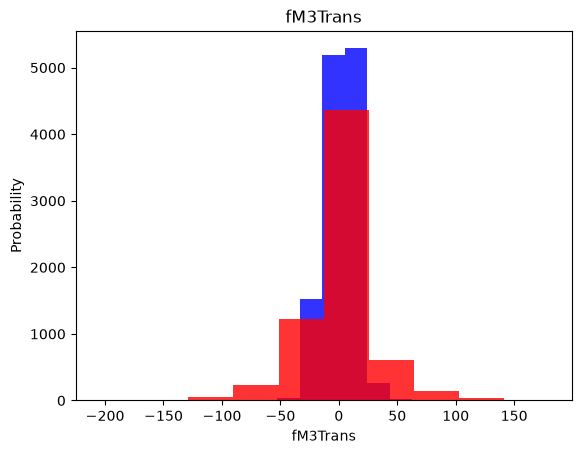

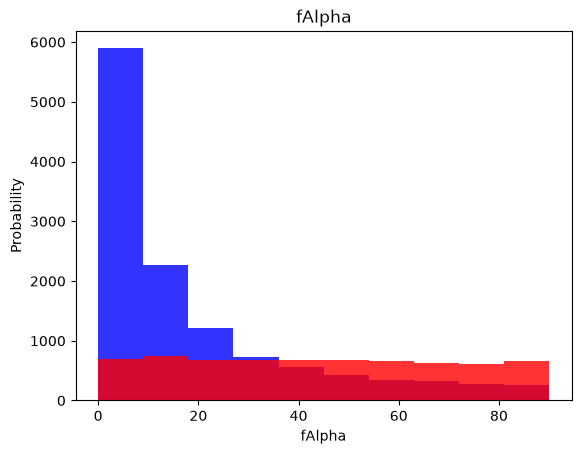

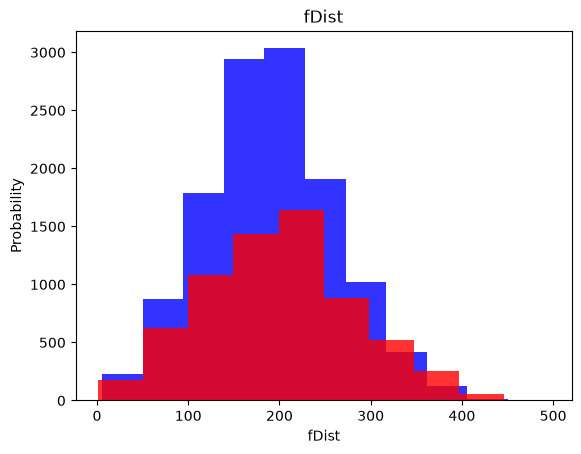

In [44]:
for labels in colms [:-1] :
    plt.hist(df[df["class"]==1][labels],color='blue',label='Gamma',alpha=0.8)
    plt.hist(df[df["class"]==0][labels],color='red',label='Hydron',alpha=0.8)

    plt.title(labels)
    plt.xlabel(labels)
    plt.ylabel("Probability")
    plt.legend
    plt.show()

# Train , Validation And Train dataset

In [45]:
shuffled_df = df.sample(frac=1, random_state=40)

train = shuffled_df.iloc[:int(0.6 * len(shuffled_df))]
validate = shuffled_df.iloc[int(0.6 * len(shuffled_df)):int(0.8 * len(shuffled_df))]
test = shuffled_df.iloc[int(0.8 * len(shuffled_df)):]

In [46]:
print("df:", type(df))
print("train:", type(train))
print("validate:", type(validate))
print("test:", type(test))

df: <class 'pandas.DataFrame'>
train: <class 'pandas.DataFrame'>
validate: <class 'pandas.DataFrame'>
test: <class 'pandas.DataFrame'>


In [47]:
def scalefunction(dataframe,oversample=False) :
    x=dataframe[dataframe.columns[:-1]].values
    y=dataframe[dataframe.columns[-1]].values

    scale=StandardScaler()

    x=scale.fit_transform(x)

    if oversample :
        ros=RandomOverSampler()
        x,y =ros.fit_resample(x,y)

    data=np.hstack((x,np.reshape(y,(-1,1))))
                   
    return data,x ,y
    

We have Scale the data set , now we are checking the data whether it got scaled or not

In [48]:
scaled_train , x_train ,y_train =scalefunction(train,oversample=True)
scaled_validate , x_validate ,y_validate =scalefunction(train,oversample=False)
scaled_test , x_test ,y_test =scalefunction(train,oversample=False)

In [49]:
len(y_train==0)

14850

In [50]:
len(train==1)
len(train==0)


11412

In [51]:
sum(y_train==1)

np.int64(7425)

# KNN

KNN stands K - Nearest Neighbour . 
Knn is a method in which we find out the value of a particular prediction by  gussing according to the nearest no of neighbour 

In [52]:
from sklearn.neighbors import KNeighborsClassifier

In [53]:
knn_modle=KNeighborsClassifier(n_neighbors=3)
knn_modle.fit(x_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


Now prdicting using the Knn model we defined here 

In [54]:
y_predict=knn_modle.predict(x_test)
y_predict

array([0, 0, 1, ..., 1, 1, 0], shape=(11412,))

Now since we have predictaded the Modle of x_ test now we will be checking its accuracy by comparing the predicto=ion and actual values

In [55]:
from sklearn.metrics import classification_report

In [56]:
print(classification_report(y_test,y_predict))


              precision    recall  f1-score   support

           0       0.86      0.91      0.88      3987
           1       0.95      0.92      0.93      7425

    accuracy                           0.92     11412
   macro avg       0.90      0.91      0.91     11412
weighted avg       0.92      0.92      0.92     11412



We can clearly see that the accuracy of our code is 1.00 which means accuracy is 100 %  the f-1 score represent the accuracy

In [57]:
print("Kab khatam hoga bea ye waaala leacture")

Kab khatam hoga bea ye waaala leacture


# Navies Bayes Application

In [58]:
from sklearn.naive_bayes import GaussianNB

In [59]:
nb_model=GaussianNB()
nb_model=nb_model.fit(x_train,y_train)

Now we have successfully used the navies bayer probablity function now testing it

In [60]:
y_predict_nb=nb_model.predict(x_test)
print(classification_report(y_test,y_predict_nb))

              precision    recall  f1-score   support

           0       0.68      0.41      0.51      3987
           1       0.74      0.89      0.81      7425

    accuracy                           0.73     11412
   macro avg       0.71      0.65      0.66     11412
weighted avg       0.72      0.73      0.71     11412



Now from the accuracy tab it is clear that with the use of navies bayers we get the accuracy of just 73 percent which is not enough .

What we have done in the navies bayers prediction is that :: First we started by importing the functions from the sklearn liberary , thereafter we created a function which held the us the GaussianNb function . then we used the gaussian nb function to predict between the x_training model and y_training model , once we have done our work with the navies bayers model . Now we will be checking the Accuracy of naive model . TO do that we first predicted the y_pred_nb by the use of gaussaian model , then using classsification report we can check the accuracy 

# Logirithmic Model Training

In [61]:
from sklearn.linear_model import LogisticRegression

In [62]:
lg_model=LogisticRegression()
lg_model=lg_model.fit(x_train,y_train)

In [63]:
y_lg_pred=lg_model.predict(x_test)
print(classification_report(y_test,y_lg_pred))

              precision    recall  f1-score   support

           0       0.69      0.72      0.70      3987
           1       0.85      0.82      0.84      7425

    accuracy                           0.79     11412
   macro avg       0.77      0.77      0.77     11412
weighted avg       0.79      0.79      0.79     11412



# Support Vector Machine (SVM)

SVM is a machinishm that uses vector to predict

In [64]:
from sklearn.svm import SVC

In [65]:
svc_model=SVC()
svc_model=svc_model.fit(x_train,y_train)

In [66]:
y_predict_svc=svc_model.predict(x_test)
print(classification_report(y_test,y_predict_svc))

              precision    recall  f1-score   support

           0       0.82      0.81      0.82      3987
           1       0.90      0.90      0.90      7425

    accuracy                           0.87     11412
   macro avg       0.86      0.86      0.86     11412
weighted avg       0.87      0.87      0.87     11412



# Neural Networks


# Tensor FLow

Tensor FLow is an Open source Libereary that allows us to implement algorithms efficiently

In [67]:
import tensorflow as tf

In [82]:
def plot_accuracy(history):
    plt.plot(history.history['loss'],label='loss')
    plt.plot(history.history['val_loss'],label='val_loss')
    plt.xlabel('Epoch')
    plt.ylabel('Binary Crossentroy')
    plt.legend()
    plt.grid(True)
    plt.show()

    
def plot_loss(history):
    plt.plot(history.history['accuracy'],label='accuracy')
    plt.plot(history.history['val_accuracy'],label='val_accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
def train_model(x_train,y_train,lr,num_nodes,batchsize,epoch,drop_pred):
    nn_model=tf.keras.Sequential([
        tf.keras.layers.Dense(num_nodes,activation='relu',input_shape=(10,)),
        tf.keras.layers.Dropout(drop_pred),
        tf.keras.layers.Dense(num_nodes,activation='relu'),
        tf.keras.layers.Dropout(drop_pred),
        tf.keras.layers.Dense(1,activation='sigmoid'),
    ])
    nn_model.compile(optimizer=tf.keras.optimizers.Adam(lr),loss='binary_crossentropy',metrics=['accuracy'])

    history=nn_model(x_train,y_train,epoch=epoch,batch_size=batchsize,validation_split=0.2,verbrose=0)

    
    return nn_model,history 



In [86]:
epoch=100
for num_nodes in[16,32,64]:
    for drop_pred in [0,0.2]:
        for lr in [0.01,0.005,0.001]:
            for batchsize in [32,64,128]:
                nn_model,history=train_model(x_train,y_train,lr,num_nodes,batchsize,epoch,drop_pred)

c:\Users\Acer\Desktop\CODING\Python\Machine_learning\.magicvenv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


TypeError: Sequential.call() got multiple values for argument 'training'

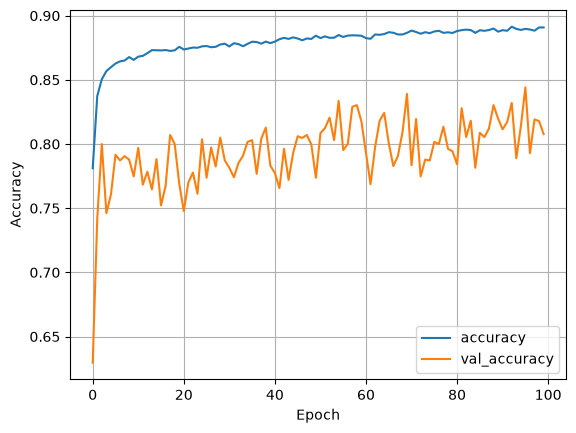

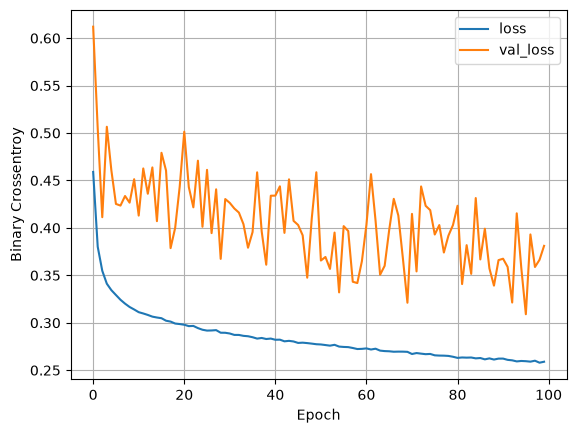

In [83]:
plot_loss(history)
plot_accuracy(history)